In [2]:
import duckdb
import numpy as np
import pandas as pd
import dask.dataframe as ddf
from dask.dataframe import from_pandas
from dask.diagnostics import ProgressBar
from matplotlib import pyplot as plt
import seaborn as sns

In [37]:
con = duckdb.connect('C:\\Users\\melvi\\Documents\\OpenF1DataWarehouse\\openf1_warehouse.duckdb')

In [4]:
# HYPOTHESIS 6 - Pit stop lap vs final position per final_position
hyp6_df = con.execute("""
                    WITH race_length AS (
                        SELECT
                            session_key,
                            MAX(lap_number) AS total_laps
                        FROM fact_laps
                        GROUP BY session_key
                    ),

                    stint_summary AS (
                        SELECT 
                            sts.session_key,
                            sts.driver_number,
                            AVG(sts.lap_start) AS avg_pit_lap,
                            AVG(CAST(sts.lap_start AS DOUBLE) / rl.total_laps) AS avg_pit_pct,
                            STDDEV(sts.lap_start) AS pit_lap_variability
                        FROM fact_stints sts
                        JOIN race_length rl 
                            ON sts.session_key = rl.session_key
                        GROUP BY sts.session_key, sts.driver_number
                    )

                    SELECT
                        s.position AS final_position,
                        ROUND(AVG(sts.avg_pit_lap), 2) AS avg_pit_lap,
                        ROUND(AVG(sts.avg_pit_pct), 2) AS pct_of_race,
                        AVG(sts.pit_lap_variability) AS avg_variability
                    FROM stint_summary sts
                    LEFT JOIN fact_session_result s 
                        ON sts.session_key = s.session_key
                        AND sts.driver_number = s.driver_number
                    WHERE s.position <= 20
                    GROUP BY s.position
                    ORDER BY s.position """).fetchdf()

In [5]:
hyp6_ddf = ddf.from_pandas(hyp6_df)

In [6]:
hyp6_ddf.describe().compute()

,final_position,avg_pit_lap,pct_of_race,avg_variability
count,20.00000,20.000000,20.00000,20.000000
mean,10.50000,10.450500,0.30300,9.213660
std,5.91608,1.533687,0.03785,1.112619
min,1.00000,6.540000,0.22000,6.077033
25%,5.75000,10.032500,0.28250,9.039255
50%,10.50000,10.975000,0.31500,9.606559
75%,15.25000,11.557500,0.33000,9.921927
max,20.00000,12.020000,0.34000,10.395946


## Hypothesis 6: Pit Timing (% of Race) and Consistency (Variability) by Final Position Plots

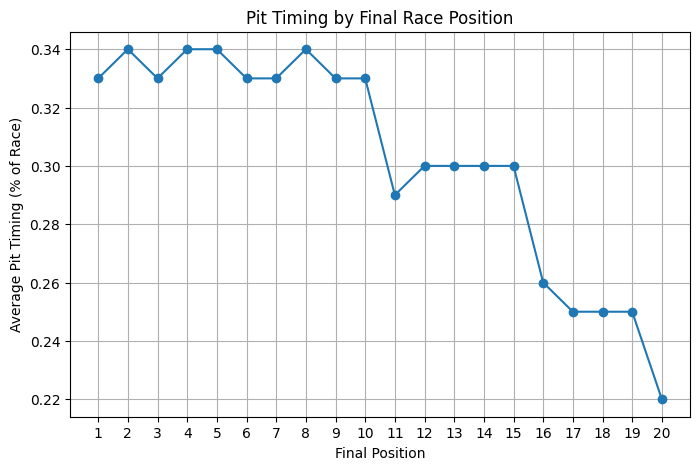

In [7]:
# Percent of race vs final position
plt.figure(figsize=(8,5))
plt.plot(hyp6_ddf['final_position'].compute(), hyp6_ddf['pct_of_race'].compute(), marker='o')

plt.xlabel('Final Position')
plt.ylabel('Average Pit Timing (% of Race)')
plt.title('Pit Timing by Final Race Position')
plt.xticks(range(1, 21))
plt.grid(True)

plt.show()

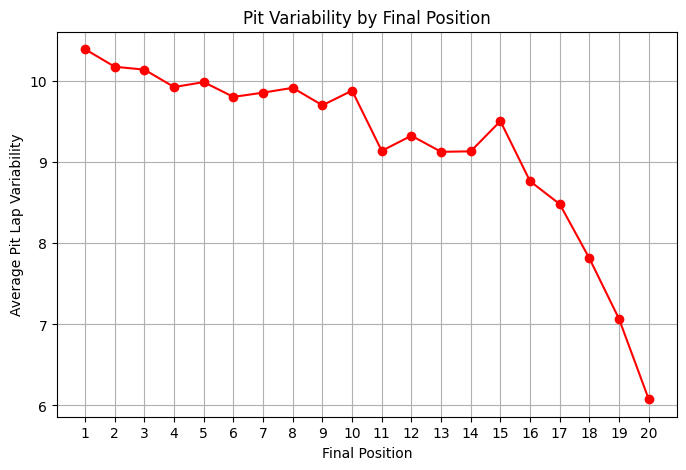

In [8]:
# Consistency through Variability by final position
plt.figure(figsize=(8,5))
plt.plot(hyp6_ddf['final_position'].compute(), hyp6_ddf['avg_variability'].compute(), marker='o', color='r')

plt.xlabel('Final Position')
plt.ylabel('Average Pit Lap Variability')
plt.title('Pit Variability by Final Position')
plt.xticks(range(1, 21))
plt.grid(True)

plt.show()

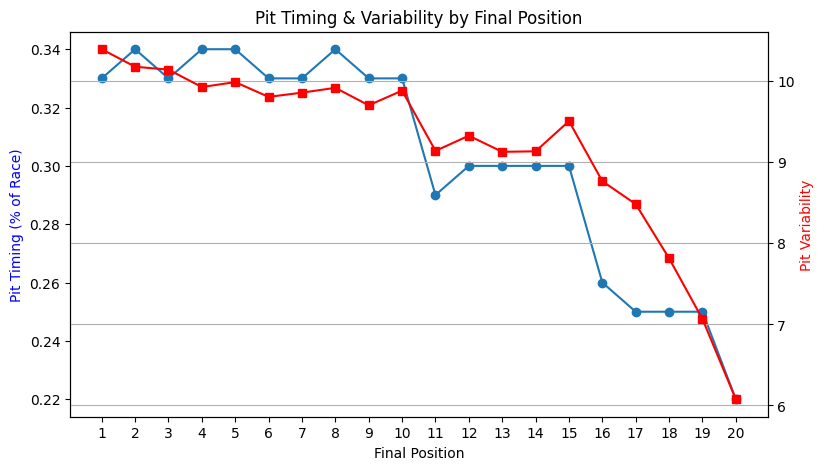

In [44]:
# Combine both for visualization
fig, ax1 = plt.subplots(figsize=(9,5))

# Percent of race where certain Final Positions have a Pit Stop
# (Left y-axis)
ax1.plot(
    hyp6_ddf['final_position'].compute(),
    hyp6_ddf['pct_of_race'].compute(),
    marker='o'
)
ax1.set_xlabel('Final Position')
ax1.set_ylabel('Pit Timing (% of Race)', color='b')

# Variability in which those Final Positions have a Pit Stop across all races
# (Right y-axis)
ax2 = ax1.twinx()
ax2.plot(
    hyp6_ddf['final_position'].compute(),
    hyp6_ddf['avg_variability'].compute(),
    marker='s', color='r'
)
ax2.set_ylabel('Pit Variability', color='r')

plt.title('Pit Timing & Variability by Final Position')
plt.xticks(range(1, 21))
plt.grid(True)

plt.show()

- Top 10 Positions:
    - Higher Variability in pit timing (within 10 laps).
    - Higher performing racers have flexible pit strategies.
    - These racers seem to aim for a pit around 32%-34% of a race.
    - Higher performing F1 racers tend to target a 25%-40% range of a race.
- Bottom 10 Positions:
    - Pit variability ranges, but is usually lower range of a race.
    - May indicate lower performing racers have consistent pit strategies   although not as flexible.
    - These racers pit earlier in races than higher performing racers.

## Hypothesis 7: Average Finishing Position by Country Bar Chart

In [38]:
# HYPOTHESIS 7 - Comparing average finishing position by country
# Must filter out low race count countries.
hyp7_df = con.execute ("""
                    SELECT d.country_code,
                        ROUND(AVG(s.position), 2) AS avg_finish_position,
                        COUNT(*) AS race_count
                    FROM fact_session_result s
                    LEFT JOIN dim_drivers d ON s.driver_number = d.driver_number
                    WHERE d.country_code IS NOT NULL
                    GROUP BY d.country_code
                    HAVING COUNT(*) > 10000
                    ORDER BY avg_finish_position """).fetchdf()

In [39]:
hyp7_ddf = ddf.from_pandas(hyp7_df)
hyp7_ddf.describe().compute()

,avg_finish_position,race_count
count,15.000000,15.000000
mean,10.737333,98696.400000
std,3.806150,59157.092034
min,4.180000,33115.000000
25%,7.920000,58601.500000
50%,12.250000,86210.000000
75%,13.340000,98379.500000
max,16.000000,257525.000000


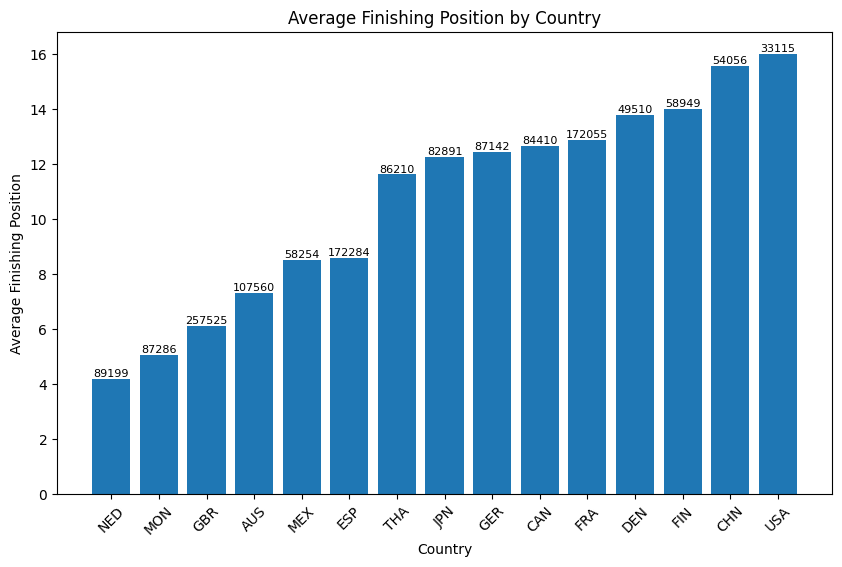

In [ ]:
hyp7ddf_plot = hyp7_ddf.sort_values('avg_finish_position').compute()

plt.figure(figsize=(10,6))
bars = plt.bar(hyp7ddf_plot['country_code'], hyp7ddf_plot['avg_finish_position'])

# Add race_count labels above bars
for i, count in enumerate(hyp7ddf_plot['race_count']):
    plt.text(
        i,
        hyp7ddf_plot['avg_finish_position'].iloc[i], 
        f'{int(count)}',
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.xlabel('Country')
plt.ylabel('Average Finishing Position')
plt.title('Average Finishing Position by Country')

plt.xticks(rotation=45)

plt.show()

- By Average Finishing Position Alone:
    - GBR (UK) is among the top
    - NED and MON rank higher
- Results affected by total races participated
    - Varying amounts of participation across selected countries

# Hypothesis 8 - Comparing Speed Trap Speed with Duration in Pit

In [13]:
# HYPOTHESIS 8 - Comparing speed trap speed with duration in pit
hyp8_df = con.execute("""
                    SELECT 
                        l.session_key, l.driver_number,
                        l.st_speed,
                        p.pit_duration
                    FROM fact_laps l
                    LEFT JOIN fact_pit p ON l.session_key = p.session_key
                        AND l.driver_number = p.driver_number
                        AND l.lap_number = p.lap_number
                    WHERE l.st_speed IS NOT NULL
                        AND p.pit_duration IS NOT NULL """).fetchdf()

In [14]:
# Per Driver/Session
hyp8_per_driver_df = con.execute("""
                    SELECT 
                        l.session_key,
                        l.driver_number,
                        AVG(l.st_speed) AS avg_speed,
                        AVG(p.pit_duration) AS avg_pit_duration
                    FROM fact_laps l
                    LEFT JOIN fact_pit p ON l.session_key = p.session_key
                        AND l.driver_number = p.driver_number
                        AND l.lap_number = p.lap_number
                    WHERE l.st_speed IS NOT NULL
                        AND p.pit_duration IS NOT NULL 
                    GROUP BY l.session_key, l.driver_number """).fetchdf()
hyp8_per_driver_df

,session_key,driver_number,avg_speed,avg_pit_duration
0,10016,6,255.60,202.860
1,10016,18,278.00,412.500
2,10016,31,251.75,561.650
3,10016,10,278.75,532.450
4,10017,63,249.40,154.500
...,...,...,...,...
5420,9618,81,296.00,357.900
5421,9620,1,241.75,346.650
5422,9620,27,284.50,566.400
5423,9621,77,276.00,272.775


In [15]:
# By Team instead
hyp8_by_team_df = con.execute("""
                    SELECT 
                        l.session_key,
                        d.team_name,
                        AVG(l.st_speed) AS avg_speed,
                        AVG(p.pit_duration) AS avg_pit_duration,
                        COUNT(*) AS size
                    FROM fact_laps l
                    LEFT JOIN fact_pit p ON l.session_key = p.session_key
                        AND l.driver_number = p.driver_number
                        AND l.lap_number = p.lap_number
                    LEFT JOIN dim_drivers d ON l.driver_number = d.driver_number
                    WHERE l.st_speed IS NOT NULL
                        AND p.pit_duration IS NOT NULL
                        AND d.team_name IS NOT NULL
                    GROUP BY l.session_key, d.team_name
                    HAVING size > 20 """).fetchdf()
hyp8_by_team_df

,session_key,team_name,avg_speed,avg_pit_duration,size
0,9096,Mercedes,231.601990,274.360199,2613
1,9096,Audi,238.333333,330.600000,378
2,9105,RB,217.500000,342.050000,244
3,9106,Alfa Romeo,231.000000,112.975000,444
4,9111,Haas F1 Team,239.640588,460.157752,2109
...,...,...,...,...,...
4025,9928,Williams,293.670779,22.243277,1540
4026,9928,McLaren,285.349862,21.033835,1089
4027,9928,Haas F1 Team,296.172557,21.630960,481
4028,9864,Aston Martin,173.921466,1329.142932,955


In [16]:
# Using By Team instead
hyp8_ddf = ddf.from_pandas(hyp8_by_team_df)
hyp8_ddf.describe().compute()

,session_key,avg_speed,avg_pit_duration,size
count,4030.000000,4030.000000,4030.000000,4030.000000
mean,9721.213648,238.619363,333.594311,1687.892556
std,534.121543,54.395573,290.748133,1706.261795
min,9095.000000,52.333333,14.996392,23.000000
25%,9468.000000,205.129349,138.224875,488.000000
50%,9608.000000,248.666667,301.928050,1159.000000
75%,9938.000000,279.860625,449.010750,2403.500000
max,11470.000000,346.000000,2920.800000,18993.000000


In [17]:
import sklearn

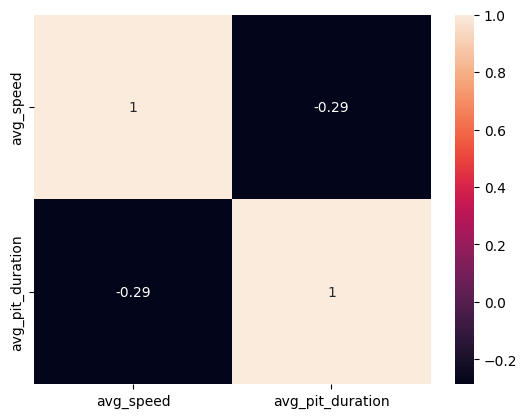

In [18]:
hyp8ddf_plot = hyp8_ddf.compute()

ax = sns.heatmap(hyp8ddf_plot[['avg_speed', 'avg_pit_duration']].corr(), annot=True)

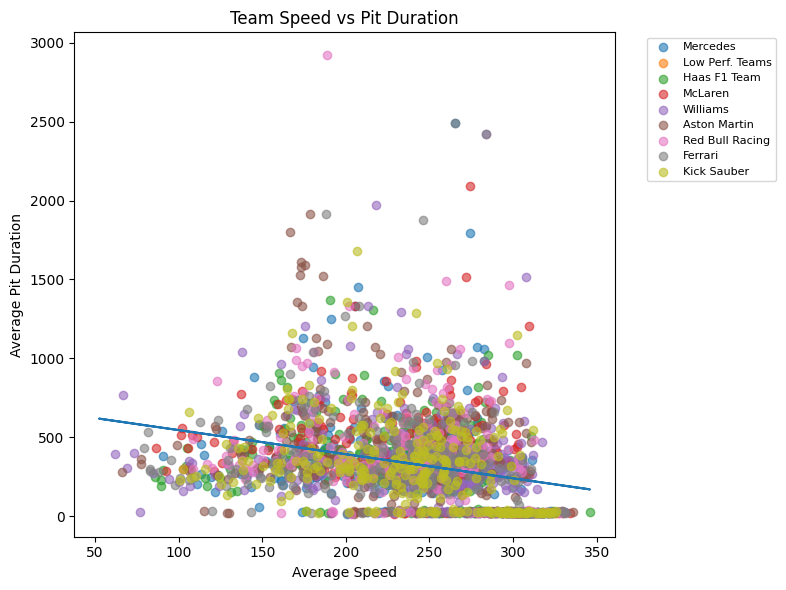

In [19]:
# Unique team names
hyp8ddf_cplot = hyp8ddf_plot.copy()
# Filter by top teams with lower performing teams as 'Low Perf. Teams'
top_teams = hyp8ddf_cplot['team_name'].value_counts().head(8).index
hyp8ddf_cplot['team_group'] = hyp8ddf_cplot['team_name'].apply(
    lambda x: x if x in top_teams else 'Low Perf. Teams'
)
teams = hyp8ddf_cplot['team_group'].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(teams)))

plt.figure(figsize=(8,6))

for team, color in zip(teams, colors):
    sub = hyp8ddf_plot[hyp8ddf_plot['team_name'] == team]

    plt.scatter(
        sub['avg_speed'],
        sub['avg_pit_duration'],
        label=team,
        alpha=0.6
    )
    
z = np.polyfit(hyp8ddf_plot['avg_speed'], hyp8ddf_plot['avg_pit_duration'], 1)
p = np.poly1d(z)

plt.plot(hyp8ddf_plot['avg_speed'], p(hyp8ddf_plot['avg_speed']))
plt.xlabel('Average Speed')
plt.ylabel('Average Pit Duration')
plt.title('Team Speed vs Pit Duration')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()

plt.show()

- Slight negative correlation (-0.29 from Heatmap)
    - Shallow slope
- Highly scattered data points 
    - Speed does not explain pit duration alone
- No clear separation between teams
    - Pit duration not strongly dependent on teams
- Pit duration influenced by other factors:
    - Race conditions
    - Race strategy

## Hypothesis 9: Starting Grid Position vs Final Position

In [20]:
# HYPOTHESIS 9 - Starting grid and final position
hyp9_df = con.execute("""
                   SELECT
                        g.driver_number,
                        g.position AS start_position,
                        s.position AS final_position
                   FROM fact_starting_grid g
                   LEFT JOIN fact_session_result s ON g.session_key = s.session_key
                        AND g.driver_number = s.driver_number
                   WHERE g.driver_number IS NOT NULL
                         AND start_position IS NOT NULL
                         AND final_position IS NOT NULL
                   GROUP BY g.session_key, g.driver_number, g.position, s.position""").fetchdf()
hyp9_df

,driver_number,start_position,final_position
0,1,1,1
1,24,13,13
2,18,6,6
3,24,17,17
4,20,16,18
...,...,...,...
1769,4,1,1
1770,87,18,8
1771,87,12,12
1772,87,9,9


In [21]:
hyp9_ddf = ddf.from_pandas(hyp9_df)
hyp9_ddf.describe().compute()

,driver_number,start_position,final_position
count,1774.000000,1774.000000,1774.000000
mean,28.943067,10.372604,10.374859
std,23.912574,5.713043,5.713587
min,1.000000,1.000000,1.000000
25%,11.000000,5.000000,5.000000
50%,22.000000,10.000000,10.000000
75%,44.000000,15.000000,15.000000
max,87.000000,22.000000,22.000000


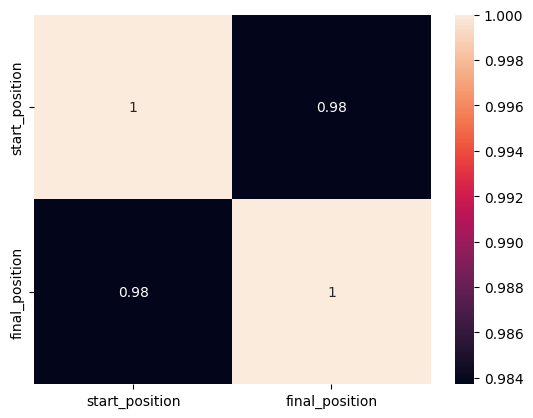

In [22]:
hyp9ddf_plot = hyp9_ddf.compute()

ax2 = sns.heatmap(hyp9ddf_plot[['start_position', 'final_position']].corr(), annot=True)

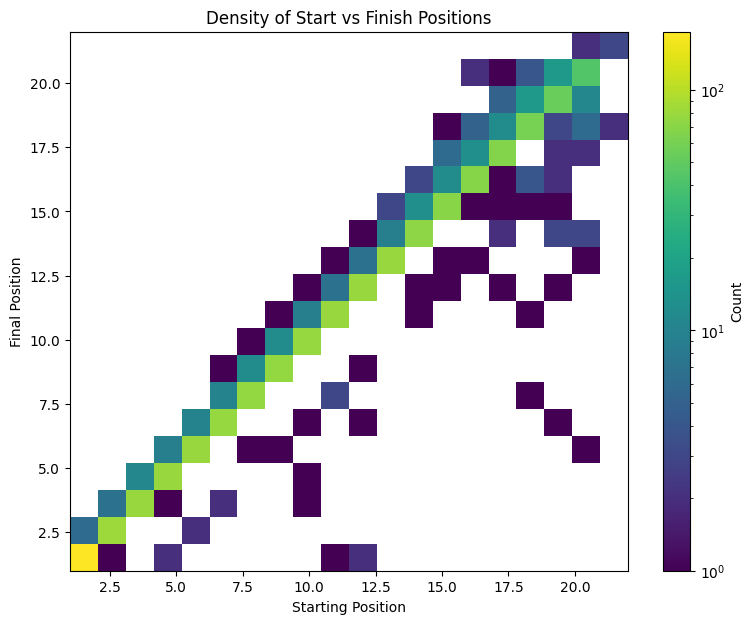

In [23]:
plt.figure(figsize=(9,7))

plt.hist2d(
    hyp9ddf_plot['start_position'],
    hyp9ddf_plot['final_position'],
    bins=20,
    # Avoiding denser areas dominating the heatmap
    norm=plt.cm.colors.LogNorm()
)

plt.colorbar(label='Count')
plt.xlabel('Starting Position')
plt.ylabel('Final Position')
plt.title('Density of Start vs Finish Positions')

plt.show()

- Log-scale applied to better visualize low density regions.
- Strong positive correlation (0.98 from previous Heatmap)
    - Front starting grid usually finish near the front
    - Back starting grid -> near the back
- Diagonals:
    - On: No position change
    - Above: Lost position since start
    - Below: Gained position since start
- Overtaking may not change outcomes significantly for most racers
- Slight spread around diagonal, some racers gain/lose positions

## Hypothesis 10: Performance of Tyre Compounds

In [24]:
# HYPOTHESIS 10 - Performance of tyre compounds based on average lap_duration and number_overtakes
hyp10_df = con.execute("""
                   SELECT
                        s.compound,
                        AVG(l.lap_duration) AS avg_lap_time,
                        COUNT(o.overtaking_driver_number) AS overtakes
                   FROM fact_stints s
                   LEFT JOIN fact_laps l ON s.session_key = l.session_key
                        AND s.driver_number = l.driver_number
                        AND l.lap_number BETWEEN s.lap_start AND s.lap_end
                   LEFT JOIN fact_overtakes o ON s.session_key = o.session_key
                        AND s.driver_number = o.overtaking_driver_number
                   GROUP BY s.compound
                   ORDER BY overtakes DESC""").fetchdf()
hyp10_df

,compound,avg_lap_time,overtakes
0,HARD,95.870246,498505
1,MEDIUM,104.097881,391907
2,SOFT,132.197331,153501
3,INTERMEDIATE,134.040833,55732
4,WET,172.009688,1487
5,None,139.837861,1037
6,UNKNOWN,304.075023,3
7,TEST_UNKNOWN,209.693203,0


In [25]:
hyp10_alt = con.execute("""
                    WITH stint_laps AS (
                        SELECT
                            s.session_key,
                            s.driver_number,
                            s.compound,
                            COUNT(l.lap_number) AS total_laps,
                            AVG(l.lap_duration) AS avg_lap_time
                        FROM fact_stints s
                        JOIN fact_laps l ON s.session_key = l.session_key
                            AND s.driver_number = l.driver_number
                            AND l.lap_number BETWEEN s.lap_start AND s.lap_end
                        GROUP BY s.session_key, s.driver_number, s.compound
                   ),
                   
                   stint_overtakes AS (
                        SELECT
                            session_key,
                            overtaking_driver_number AS driver_number,
                            COUNT(*) AS overtakes
                        FROM fact_overtakes
                        GROUP BY session_key, overtaking_driver_number
                   )
                   
                   SELECT
                        sl.compound,
                        ROUND(AVG(sl.avg_lap_time), 3) AS avg_lap_time,
                        ROUND(AVG(COALESCE(so.overtakes, 0) / sl.total_laps), 3) AS overtakes_per_lap,
                        COUNT(*) AS stint_count
                   FROM stint_laps sl
                   LEFT JOIN stint_overtakes so ON sl.session_key = so.session_key 
                        AND sl.driver_number = so.driver_number
                   WHERE sl.compound IS NOT NULL
                        AND sl.compound IN ('SOFT', 'MEDIUM', 'HARD', 'INTERMEDIATE', 'WET')
                   GROUP BY sl.compound
                   ORDER BY avg_lap_time """).fetch_df()
# .dtypes show 'compound' as string[pyarrow], cast as string
hyp10_alt['compound'] = hyp10_alt['compound'].astype(str)

In [26]:
hyp10_ddf = ddf.from_pandas(hyp10_alt)
hyp10_ddf.compute()

,compound,avg_lap_time,overtakes_per_lap,stint_count
0,HARD,142.682,0.267,2300
1,MEDIUM,159.798,0.325,4288
2,SOFT,213.437,0.163,5287
3,INTERMEDIATE,256.323,0.568,675
4,WET,380.189,0.901,152


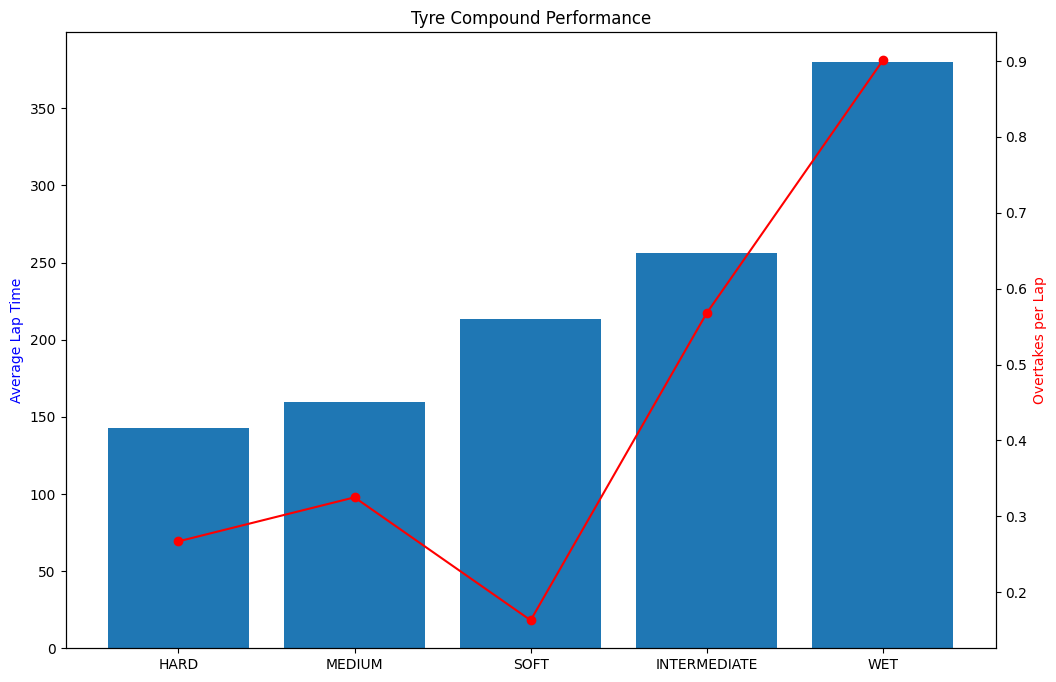

In [27]:
hyp10ddf_plot = hyp10_ddf.compute()

ddf10 = hyp10ddf_plot.copy()
fig, ax1 = plt.subplots(figsize=(12,8))

ax1.bar(ddf10['compound'], ddf10['avg_lap_time'])
ax1.set_ylabel('Average Lap Time', color='b')

ax2 = ax1.twinx()
ax2.plot(ddf10['compound'], ddf10['overtakes_per_lap'], marker='o', color='r')
ax2.set_ylabel('Overtakes per Lap', color ='r')

plt.title('Tyre Compound Performance')
plt.show()

- Dual metric graph:
    - Blue Bars: Avg Lap Time
    - Red Line: Overtakes per lap
- Limitations of graph:
    - Does not account for different track/weather conditions
    - ... fuel/load conditions
    - WET and INTERMEDIATE have low stint counts compared to HARD, MEDIUM, SOFT
- FROM F1 website:
    - SOFT tyres offer more grip, quicker to degrade -> faster lap times more ideal for qualifying runs.
    - HARD tyres offer less grip, lasts longer -> slower lap times
- Graph seems to support that information

## Hypothesis 16: Average number of Black and White flags and Finishing Position

In [28]:
# HYPOTHESIS 16 - Number of BLACK AND WHITE flags per final_position 
# Not enough data for conlusive result.
print(con.execute ("""
                   SELECT 
                        s.position as final_position,
                        COUNT(r.flag) as BW_flag_count
                   FROM main.fact_session_result s
                   LEFT JOIN main.fact_race_control r ON s.session_key = r.session_key
                         AND s.driver_number = r.driver_number
                   WHERE r.driver_number IS NOT NULL 
                        AND r.flag = 'BLACK AND WHITE'
                        AND s.position IS NOT NULL
                   GROUP BY s.position """).fetchdf())

    final_position  BW_flag_count
0                1              3
1                2              3
2                3              4
3                4              4
4                5              7
5                6              8
6                7              3
7                8              8
8                9              6
9               10              7
10              11              6
11              12              5
12              13              7
13              14             11
14              15              6
15              16              6
16              17              8
17              18              9
18              19              5
19              20              5


In [ ]:
# HYPOTHESIS 16 ALT - Flag types based on race phase
hyp16_alt = con.execute("""
                        SELECT
                            CASE
                                WHEN lap_number <= 10 THEN 'Early Race (1-10)'
                                WHEN lap_number <= 30 THEN 'Mid Race (11-30)'
                                ELSE 'Late Race (31+)'
                            END AS race_phase,
                            COUNT(*) AS event_count,
                            flag
                        FROM fact_race_control
                        WHERE lap_number IS NOT NULL
                            AND flag IS NOT NULL
                        GROUP BY race_phase, flag
                        ORDER BY race_phase """).fetchdf()
hyp16_alt['race_phase'] = hyp16_alt['race_phase'].astype(str)
hyp16_alt['flag'] = hyp16_alt['flag'].astype(str)
hyp16_alt

,race_phase,event_count,flag
0,Early Race (1-10),182,GREEN
1,Early Race (1-10),480,CLEAR
2,Early Race (1-10),247,DOUBLE YELLOW
3,Early Race (1-10),4,BLACK AND WHITE
4,Early Race (1-10),181,YELLOW
5,Early Race (1-10),7,RED
6,Early Race (1-10),6,BLUE
7,Late Race (31+),58,BLACK AND WHITE
8,Late Race (31+),72,CHEQUERED
9,Late Race (31+),88,DOUBLE YELLOW


In [30]:
hyp16_ddf = ddf.from_pandas(hyp16_alt)
hyp16_ddf.dtypes

race_phase     string[pyarrow]
event_count              int64
flag           string[pyarrow]
dtype: object

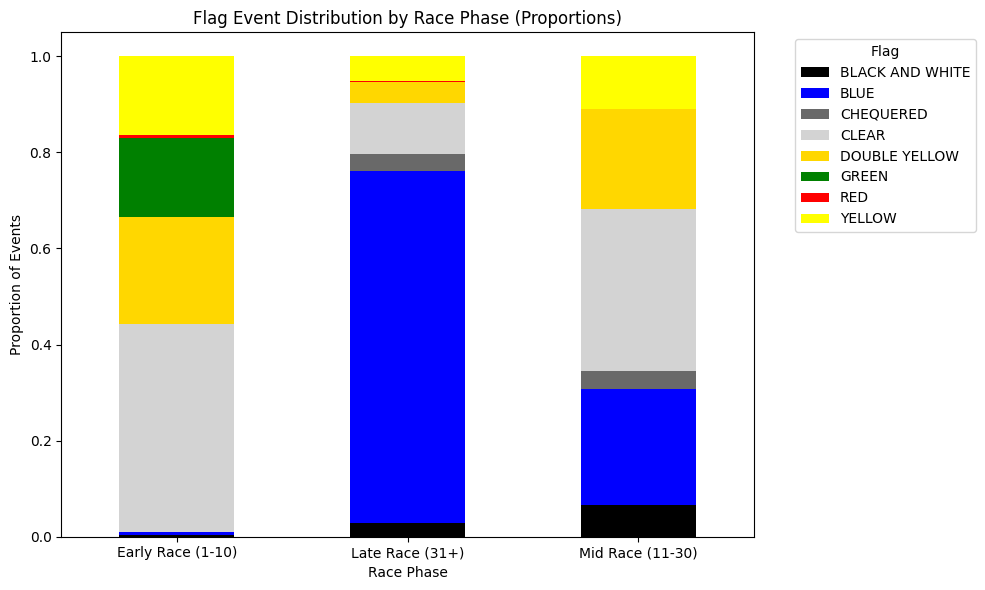

In [42]:
hyp16_plot = hyp16_ddf.compute()

flag_colors = {
    'BLACK AND WHITE': 'black',   
    'BLUE': 'blue',
    'CHEQUERED': 'dimgray',         
    'CLEAR': 'lightgray',         
    'DOUBLE YELLOW': 'gold',      
    'GREEN': 'green',
    'RED': 'red',
    'YELLOW': 'yellow'
}

# Normalize by race phase
pivot = hyp16_plot.pivot(index='race_phase', columns='flag', values='event_count').fillna(0)
pivot_norm = pivot.div(pivot.sum(axis=1), axis=0)

colors = [flag_colors.get(col, 'gray') for col in pivot_norm.columns]
# ax = pivot_norm.plot(kind='bar', stacked=True, figsize=(10,6))
ax = pivot_norm.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6),
    color=colors
)

ax.set_title('Flag Event Distribution by Race Phase (Proportions)')
ax.set_xlabel('Race Phase')
ax.set_ylabel('Proportion of Events')

plt.xticks(rotation=0)
plt.legend(title='Flag', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()


ALT Hypothesis 16 - How does the composition of flag events change throughout a race?
    a. Predict that earlier laps in a race consists of incident type flags, later laps consist of traffic management type flags.
- Early Race
- Mid Race
- Late Race

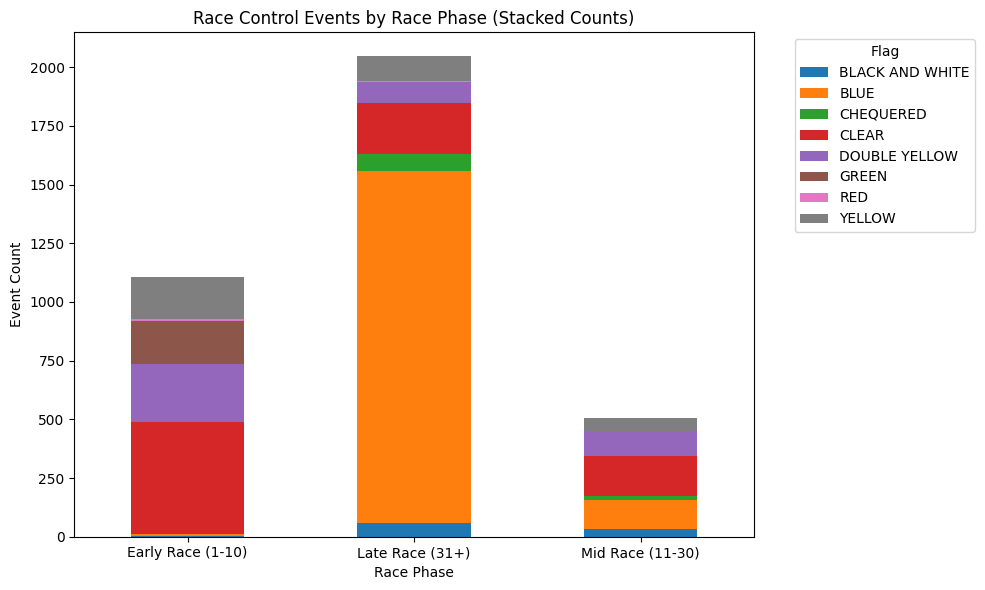

In [33]:
# Plot based on count
ax = pivot.plot(kind='bar', stacked=True, figsize=(10,6))

ax.set_title('Race Control Events by Race Phase (Stacked Counts)')
ax.set_xlabel('Race Phase')
ax.set_ylabel('Event Count')

plt.xticks(rotation=0)
plt.legend(title='Flag', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

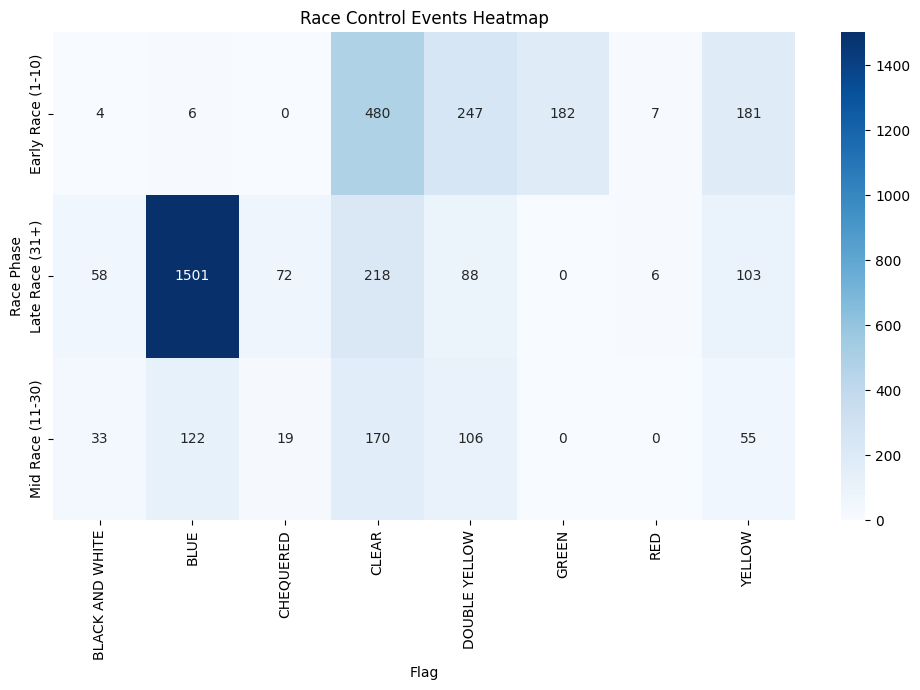

In [34]:
plt.figure(figsize=(10,7))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".0f",
    cmap="Blues"
)

plt.title('Race Control Events Heatmap')
plt.xlabel('Flag')
plt.ylabel('Race Phase')

plt.tight_layout()
plt.show()

In [35]:
con.close()